# Etape 1 - Importation des librairies et chargement du fichier

### 1.1 - Importation des librairies

In [ ]:
#Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr

#Importation de la librairie plotly express
import plotly.express as px

In [ ]:
#afficher toutes les colonnes de mon dataframe
pd.set_option('display.max_columns', None)

### 1.2 - Chargements du fichier

In [ ]:
#Importation du fichier Données complètes2.csv
df_poulet = pd.read_csv("Données complètes2.csv",sep=";", decimal=",")

# Etape 2 - Analyse exploratoire du fichier

### 2.1 - Analyse exploratoire du fichier

In [ ]:
# Pour info on a prit ici les données pour 2017 et pour ce qui est des infos sur l'import export dispo alimentaire, c'est celles concernant la volaille

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} pays(s)".format(df_poulet.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_poulet.shape[1]))

Le tableau comporte 125 pays(s)
Le tableau comporte 11 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de : ",df_poulet.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Nature des données pour chaques colonnes :\n", df_poulet.dtypes,"\n")
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs par colonnes :\n", df_poulet.count())

#La disponibilité alimentaire en quantité (kg/personne/an) constitue une approximation de la consommation moyenne de viande de volaille par habitant dans un pays.

Le nombre de colonnes est de :  11 

Nature des données pour chaques colonnes :
 Zone                                                       object
Production                                                  int64
Importations - Quantité                                     int64
Disponibilité intérieure                                    int64
Disponibilité alimentaire en quantité (kg/personne/an)    float64
Exportations - Quantité                                   float64
Population                                                  int64
Population urbaine                                          int64
PIB par habitant annuel en 2017 ($)                       float64
Stabilité politique                                       float64
Valeur index infrastructure                               float64
dtype: object 

Nombre de valeurs par colonnes :
 Zone                                                      125
Production                                                125
Importations - Quan

In [ ]:
#Afficher les 5 premières lignes de la table
df_poulet.head()

,Zone,Production,Importations - Quantité,Disponibilité intérieure,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,Population urbaine,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure
0,Albanie,13000000,38000000,47000000,16.36,0.0,2884169,1740032,4213.46,0.38,3.56
1,Algérie,275000000,2000000,277000000,6.38,0.0,41389189,29770610,4162.15,-0.92,3.56
2,Argentine,2161000000,8000000,1962000000,42.24,207000000.0,43937140,40618237,14660.23,0.17,3.85
3,Arménie,11000000,35000000,47000000,16.06,0.0,2944791,1849202,3899.68,-0.62,3.85
4,Allemagne,1514000000,842000000,1739000000,19.47,646000000.0,82658409,63442124,43286.10,0.59,5.96


In [ ]:
# Remplacer les na de la colonne exportation par 0 car si il n'y a rien c'est qu'il n'y a pas eu d'exportations
df_poulet['Exportations - Quantité']=df_poulet['Exportations - Quantité'].fillna(0)
df_poulet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 11 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Zone                                                    125 non-null    object 
 1   Production                                              125 non-null    int64  
 2   Importations - Quantité                                 125 non-null    int64  
 3   Disponibilité intérieure                                125 non-null    int64  
 4   Disponibilité alimentaire en quantité (kg/personne/an)  125 non-null    float64
 5   Exportations - Quantité                                 125 non-null    float64
 6   Population                                              125 non-null    int64  
 7   Population urbaine                                      125 non-null    int64  
 8   PIB par habitant annuel en 2017 ($)     

In [ ]:
# Calculer la population totale
print(f"La population totale de l'échantillon est de : {df_poulet['Population'].sum():,} ({df_poulet.shape[0]} pays)".replace(",", " "))
#on a donc bien plus de 100 pays et une population représentée de plus de 60% de la population totale

La population totale de l'échantillon est de : 6 849 226 725 (125 pays)


# Etape 3 - Calcul de quelques indicateurs utiles

### Etape 3.1 - La dépendance aux importations

In [ ]:
df_poulet["dep_import"] = round(df_poulet['Importations - Quantité']/df_poulet['Disponibilité intérieure'],2)
display(df_poulet)

,Zone,Production,Importations - Quantité,Disponibilité intérieure,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,Population urbaine,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import
0,Albanie,13000000,38000000,47000000,16.36,0.0,2884169,1740032,4213.46,0.38,3.56,0.81
1,Algérie,275000000,2000000,277000000,6.38,0.0,41389189,29770610,4162.15,-0.92,3.56,0.01
2,Argentine,2161000000,8000000,1962000000,42.24,207000000.0,43937140,40618237,14660.23,0.17,3.85,0.00
3,Arménie,11000000,35000000,47000000,16.06,0.0,2944791,1849202,3899.68,-0.62,3.85,0.74
4,Allemagne,1514000000,842000000,1739000000,19.47,646000000.0,82658409,63442124,43286.10,0.59,5.96,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...
120,Venezuela (République bolivarienne du),600000000,25000000,626000000,20.28,0.0,29402484,28198251,7865.77,-1.25,2.63,0.04
121,Viet Nam,918000000,291000000,1206000000,12.33,1000000.0,94600648,33642498,2868.14,0.29,3.90,0.24
122,Yémen,168000000,78000000,246000000,8.53,0.0,27834819,10174612,569.89,-2.94,1.83,0.32
123,Zambie,49000000,12000000,60000000,3.42,1000000.0,16853599,7346421,1284.93,0.15,2.44,0.20


### Etape 3.2 - L'autosuffisance

In [ ]:
df_poulet["autosuffisance"] = round(df_poulet['Production']/df_poulet['Disponibilité intérieure'],2)
display(df_poulet)

,Zone,Production,Importations - Quantité,Disponibilité intérieure,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,Population urbaine,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance
0,Albanie,13000000,38000000,47000000,16.36,0.0,2884169,1740032,4213.46,0.38,3.56,0.81,0.28
1,Algérie,275000000,2000000,277000000,6.38,0.0,41389189,29770610,4162.15,-0.92,3.56,0.01,0.99
2,Argentine,2161000000,8000000,1962000000,42.24,207000000.0,43937140,40618237,14660.23,0.17,3.85,0.00,1.10
3,Arménie,11000000,35000000,47000000,16.06,0.0,2944791,1849202,3899.68,-0.62,3.85,0.74,0.23
4,Allemagne,1514000000,842000000,1739000000,19.47,646000000.0,82658409,63442124,43286.10,0.59,5.96,0.48,0.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,Venezuela (République bolivarienne du),600000000,25000000,626000000,20.28,0.0,29402484,28198251,7865.77,-1.25,2.63,0.04,0.96
121,Viet Nam,918000000,291000000,1206000000,12.33,1000000.0,94600648,33642498,2868.14,0.29,3.90,0.24,0.76
122,Yémen,168000000,78000000,246000000,8.53,0.0,27834819,10174612,569.89,-2.94,1.83,0.32,0.68
123,Zambie,49000000,12000000,60000000,3.42,1000000.0,16853599,7346421,1284.93,0.15,2.44,0.20,0.82


### Etape 3.3 - Taux de population urbaine

In [ ]:
#calcul du taux de population urbaine
df_poulet["taux_urbain"] = round(df_poulet['Population urbaine']/df_poulet['Population'],2)*100

# si un taux est supérieur a 100 alors la valeur de taux_urbain devient 100
df_poulet.loc[df_poulet["taux_urbain"] > 100, "taux_urbain"] = 100
display(df_poulet)

,Zone,Production,Importations - Quantité,Disponibilité intérieure,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,Population urbaine,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
0,Albanie,13000000,38000000,47000000,16.36,0.0,2884169,1740032,4213.46,0.38,3.56,0.81,0.28,60.0
1,Algérie,275000000,2000000,277000000,6.38,0.0,41389189,29770610,4162.15,-0.92,3.56,0.01,0.99,72.0
2,Argentine,2161000000,8000000,1962000000,42.24,207000000.0,43937140,40618237,14660.23,0.17,3.85,0.00,1.10,92.0
3,Arménie,11000000,35000000,47000000,16.06,0.0,2944791,1849202,3899.68,-0.62,3.85,0.74,0.23,63.0
4,Allemagne,1514000000,842000000,1739000000,19.47,646000000.0,82658409,63442124,43286.10,0.59,5.96,0.48,0.87,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,Venezuela (République bolivarienne du),600000000,25000000,626000000,20.28,0.0,29402484,28198251,7865.77,-1.25,2.63,0.04,0.96,96.0
121,Viet Nam,918000000,291000000,1206000000,12.33,1000000.0,94600648,33642498,2868.14,0.29,3.90,0.24,0.76,36.0
122,Yémen,168000000,78000000,246000000,8.53,0.0,27834819,10174612,569.89,-2.94,1.83,0.32,0.68,37.0
123,Zambie,49000000,12000000,60000000,3.42,1000000.0,16853599,7346421,1284.93,0.15,2.44,0.20,0.82,44.0


### Etape 3.4 - Top 10 des producteurs

In [ ]:
Top_10_prod = df_poulet.sort_values("Production", ascending=False).head(10)
Top_10_prod["Production format"] = Top_10_prod["Production"].apply(lambda x: f"{int(x):,}".replace(",", " "))

In [ ]:
# Calculer la production moyenne
prod_moyenne = int(df_poulet['Production'].mean())
print(f"La production moyenne de poulet est de {prod_moyenne:,} Kg dans le monde".replace(",", " "))

Top_10_prod["Prod_moyenne"] = f"{prod_moyenne:,}".replace(",", " ")

La production moyenne de poulet est de 916 824 000 Kg dans le monde


In [ ]:
# graphique
fig = px.bar(
    Top_10_prod,
    x='Zone',
    y='Production',
    title="Top 10 des plus gros producteur de volailles",
    labels={'Zone': 'Pays','Production': 'Production (Kg)'},
    text='Production',
    hover_data={"Production format": True, "Production": False, "Prod_moyenne": True}
)

fig.update_layout(
    height=900,
    width=1400,
    xaxis_title="Pays",
    yaxis_title="Production en (Kg)"
)

fig.show()

### Etape 3.5 - Top 10 des importateurs

In [ ]:
Top_10_import = df_poulet.sort_values("Importations - Quantité", ascending=False).head(10)
Top_10_import["Importation format"] = Top_10_import["Importations - Quantité"].apply(lambda x: f"{int(x):,}".replace(",", " "))

In [ ]:
# Calculer l'importation moyenne
import_moyenne = int(df_poulet['Importations - Quantité'].mean())
print(f"L'importation moyenne de poulet est de {import_moyenne:,} Kg dans le monde".replace(",", " "))

Top_10_import["Import_moyenne"] = f"{import_moyenne:,}".replace(",", " ")

L'importation moyenne de poulet est de 103 032 000 Kg dans le monde


In [ ]:
# graphique
fig = px.bar(
    Top_10_import,
    x='Zone',
    y='Importations - Quantité',
    title="Top 10 des plus gros importateurs de volailles",
    labels={'Zone': 'Pays','Importations - Quantité': 'Importation (Kg)'},
    text='Importations - Quantité',
    hover_data={"Importation format": True, "Importations - Quantité": False, "Import_moyenne": True}
)

fig.update_layout(
    height=900,
    width=1400,
    xaxis_title="Pays",
    yaxis_title="Importation en (Kg)"
)

fig.show()

### Etape 3.6 - Top 10 des consommateurs

In [ ]:
Top_10_conso = df_poulet.sort_values("Disponibilité alimentaire en quantité (kg/personne/an)", ascending=False).head(10)

In [ ]:
# Calculer la consommation moyenne
consommation_moyenne = round(df_poulet["Disponibilité alimentaire en quantité (kg/personne/an)"].mean(),2)
print(f"La consommation moyenne de poulet est de {consommation_moyenne} Kg/personne/an dans le monde")

Top_10_conso["Conso_moyenne"] = f"{consommation_moyenne:,}".replace(",", " ")

La consommation moyenne de poulet est de 18.93 Kg/personne/an dans le monde


In [ ]:
# graphique
fig = px.bar(
    Top_10_conso,
    x='Zone',
    y='Disponibilité alimentaire en quantité (kg/personne/an)',
    title="Top 10 des plus gros consommateurs de volailles",
    labels={'Zone': 'Pays','Disponibilité alimentaire en quantité (kg/personne/an)': 'Consommation (kg/personne/an)'},
    text='Disponibilité alimentaire en quantité (kg/personne/an)',
    hover_data={"Conso_moyenne": True}
)

fig.update_layout(
    height=900,
    width=1400,
    xaxis_title="Pays",
    yaxis_title="Consommation en (kg/personne/an)"
)

fig.show()

### Etape 3.7 - Top 10 pays les plus urbanisés

In [ ]:
Top_10_urbain = df_poulet.sort_values("taux_urbain", ascending=False).head(10)
Top_10_urbain["Population urbaine format"] = Top_10_urbain["Population urbaine"].apply(lambda x: f"{int(x):,}".replace(",", " "))


In [ ]:
# Calculer l'urbanisation moyenne
urbanisation_moyenne = round(df_poulet["taux_urbain"].mean(),2)
print(f"L'urbanisation moyenne est de {urbanisation_moyenne} % dans le monde")

Top_10_urbain["Urbanisation_moyenne (%)"] = f"{urbanisation_moyenne:,}".replace(",", " ")

L'urbanisation moyenne est de 61.82 % dans le monde


In [ ]:
fig = px.bar(
    Top_10_urbain,
    x='Zone',
    y='taux_urbain',
    title="Top 10 des pays les plus urbanisés",
    labels={'Zone': 'Pays','taux_urbain': 'Taux de population urbaine (%)'},
    text='taux_urbain',
    hover_data={"taux_urbain": True,"Urbanisation_moyenne (%)": True,"Population urbaine format": True}
)

fig.update_layout(
    height=900,
    width=1400,
    xaxis_title="Pays",
    yaxis_title="Taux de population urbaine (%)"
)

fig.show()

### Etape 3.8 - Top 10 pays les moins urbanisés

In [ ]:
Top_10_rural = df_poulet.sort_values("taux_urbain", ascending=True).head(10)

Top_10_rural["Population urbaine format"] = Top_10_rural["Population urbaine"].apply(lambda x: f"{int(x):,}".replace(",", " "))

In [ ]:
Top_10_rural["Urbanisation_moyenne (%)"] = f"{urbanisation_moyenne:,}".replace(",", " ")

In [ ]:
fig = px.bar(
    Top_10_rural,
    x='Zone',
    y='taux_urbain',
    title="Top 10 des pays les moins urbanisés",
    labels={'Zone': 'Pays','taux_urbain': 'Taux de population urbaine (%)'},
    text='taux_urbain',
    hover_data={"taux_urbain": True, "Urbanisation_moyenne (%)": True,"Population urbaine format": True}
)

fig.update_traces(textposition='auto')

fig.update_layout(
    height=900,
    width=1400,
    xaxis_title="Pays",
    yaxis_title="Taux de population urbaine (%)"
)

fig.show()

### Etape 3.9 - Analyse de la répartition des pays pour l'autosuffisance et la dépendance aux imports

array([[<Axes: title={'center': 'dep_import'}>,
        <Axes: title={'center': 'autosuffisance'}>]], dtype=object)

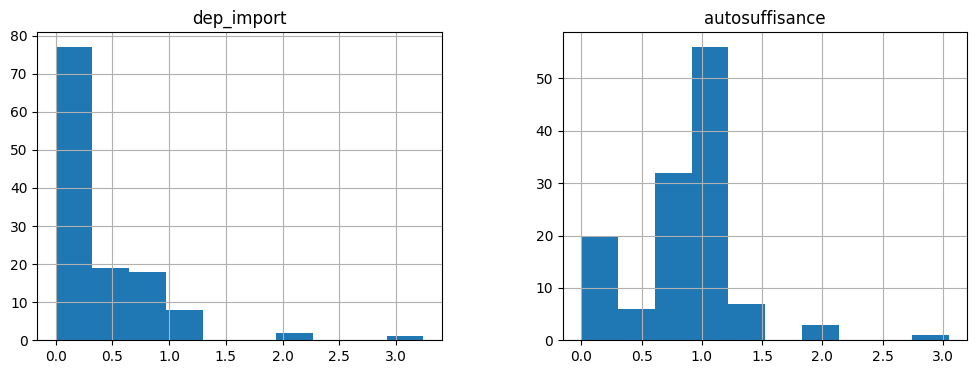

In [ ]:
cols = ["dep_import","autosuffisance",]

df_poulet[cols].hist(figsize=(12,4))

In [ ]:
for col in cols:
    fig = px.box(df_poulet,x=col,title=f"Boxplot - {col}")
    fig.show()

### Etape 3.10 - Vérification des outliers

In [ ]:
Q1 = df_poulet["dep_import"].quantile(0.25)
Q3 = df_poulet["dep_import"].quantile(0.75)
IQR = Q3 - Q1

outliers_dep = df_poulet[(df_poulet["dep_import"] < Q1 - 1.5 * IQR) | (df_poulet["dep_import"] > Q3 + 1.5 * IQR)]

outliers_dep[["Zone", "dep_import"]]

,Zone,dep_import
9,Belgique,2.22
25,Chine - RAS de Hong-Kong,3.24
34,Gambie,2.00


In [ ]:
Q1 = df_poulet["autosuffisance"].quantile(0.25)
Q3 = df_poulet["autosuffisance"].quantile(0.75)
IQR = Q3 - Q1

outliers_auto = df_poulet[(df_poulet["autosuffisance"] < Q1 - 1.5 * IQR) | (df_poulet["autosuffisance"] > Q3 + 1.5 * IQR)]

outliers_auto = outliers_auto.sort_values("autosuffisance", ascending=False)

display(outliers_auto[["Zone", "autosuffisance"]])

#on retrouve la belgique, on explique le fait que ce soit un outlier dans les deux car c'est un hub commercial, elle produit et importe beaucoup mais exporte aussi beaucoup (6X plus)

print("Exportation de volaille belge :",f"{int(df_poulet[df_poulet['Zone'] == 'Belgique']['Exportations - Quantité'].sum()):,}".replace(",", " "),"Kg")
print("Exportation de volaille moyenne mondiale :",f"{int(df_poulet['Exportations - Quantité'].mean()):,}".replace(",", " "),"Kg")

#pour ce qui est de hong-kong, c'est une ville elle produit donc assez peu et importe beaucoup ce qui est logique
#Les autres pays ayant une valeur très faible on tout simplement une production très faible de volailles

,Zone,autosuffisance
9,Belgique,3.05
91,Pologne,2.03
110,Thaïlande,1.90
44,Hongrie,1.85
115,Émirats arabes unis,0.12
63,Lesotho,0.12
10,Bénin,0.11
18,Cabo Verde,0.10
41,Haïti,0.09
25,Chine - RAS de Hong-Kong,0.09


Exportation de volaille belge : 656 000 000 Kg
Exportation de volaille moyenne mondiale : 126 648 000 Kg


# Etape 4 - Analyse des corrélations

### Etape 4.1 - Corrélation entre la stabilité politique et l'infrastructure

In [ ]:
display(df_poulet)

,Zone,Production,Importations - Quantité,Disponibilité intérieure,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,Population urbaine,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
0,Albanie,13000000,38000000,47000000,16.36,0.0,2884169,1740032,4213.46,0.38,3.56,0.81,0.28,60.0
1,Algérie,275000000,2000000,277000000,6.38,0.0,41389189,29770610,4162.15,-0.92,3.56,0.01,0.99,72.0
2,Argentine,2161000000,8000000,1962000000,42.24,207000000.0,43937140,40618237,14660.23,0.17,3.85,0.00,1.10,92.0
3,Arménie,11000000,35000000,47000000,16.06,0.0,2944791,1849202,3899.68,-0.62,3.85,0.74,0.23,63.0
4,Allemagne,1514000000,842000000,1739000000,19.47,646000000.0,82658409,63442124,43286.10,0.59,5.96,0.48,0.87,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,Venezuela (République bolivarienne du),600000000,25000000,626000000,20.28,0.0,29402484,28198251,7865.77,-1.25,2.63,0.04,0.96,96.0
121,Viet Nam,918000000,291000000,1206000000,12.33,1000000.0,94600648,33642498,2868.14,0.29,3.90,0.24,0.76,36.0
122,Yémen,168000000,78000000,246000000,8.53,0.0,27834819,10174612,569.89,-2.94,1.83,0.32,0.68,37.0
123,Zambie,49000000,12000000,60000000,3.42,1000000.0,16853599,7346421,1284.93,0.15,2.44,0.20,0.82,44.0


Coefficient de corrélation de Spearman: 0.6335210602651782
Valeur p: 2.2155999963298246e-15


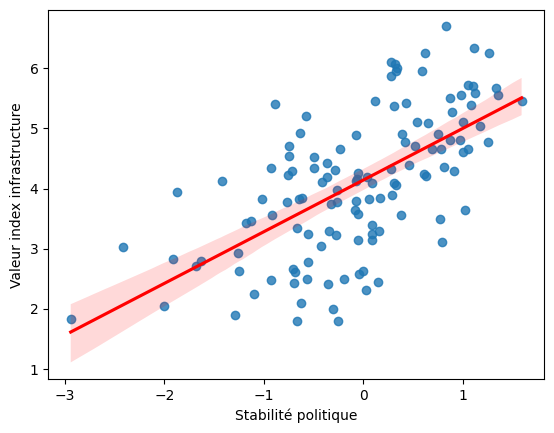

In [ ]:
# test de Spearman

# 1) Visualisation correcte
sns.regplot(data=df_poulet,x='Stabilité politique',y='Valeur index infrastructure',robust=True,line_kws=dict(color="r"))

# 2) Spearman
spearman_corr, spearman_p_value = spearmanr(df_poulet['Stabilité politique'], df_poulet['Valeur index infrastructure'])

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

### Etape 4.2 - Corrélation entre l'importation et la consommation

Coefficient de corrélation de Spearman: 0.474761823964054
Valeur p: 2.2218379292193044e-08


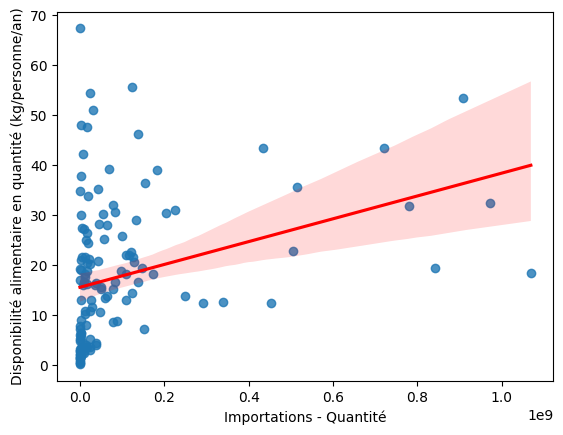

In [ ]:
# test de Spearman

# 1) Visualisation correcte
sns.regplot(data=df_poulet,x='Importations - Quantité',y='Disponibilité alimentaire en quantité (kg/personne/an)',robust=True,line_kws=dict(color="r"))

# 2) Spearman
spearman_corr, spearman_p_value = spearmanr(df_poulet['Importations - Quantité'], df_poulet['Disponibilité alimentaire en quantité (kg/personne/an)'])

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

### Etape 4.3 - Corrélation entre l'infrastructure et la consommation

Coefficient de corrélation de Spearman: 0.6812150336409596
Valeur p: 2.290037556329712e-18


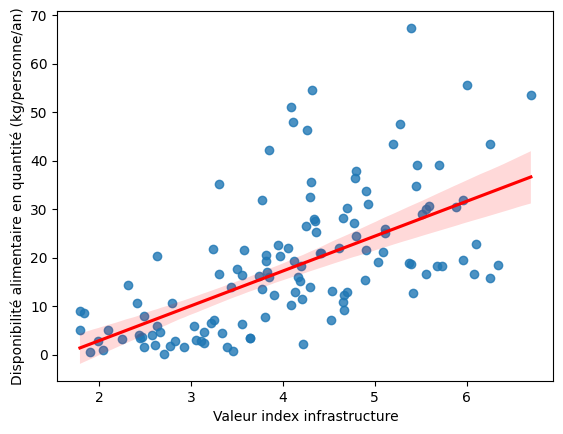

In [ ]:
# test de Spearman

# 1) Visualisation correcte
sns.regplot(data=df_poulet,x='Valeur index infrastructure',y='Disponibilité alimentaire en quantité (kg/personne/an)',robust=True,line_kws=dict(color="r"))

# 2) Spearman
spearman_corr, spearman_p_value = spearmanr(df_poulet['Valeur index infrastructure'], df_poulet['Disponibilité alimentaire en quantité (kg/personne/an)'])

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

### Etape 4.4 - Consommation vs urbanisation

Coefficient de corrélation de Spearman: 0.6979353448895793
Valeur p: 1.4962333200643026e-19


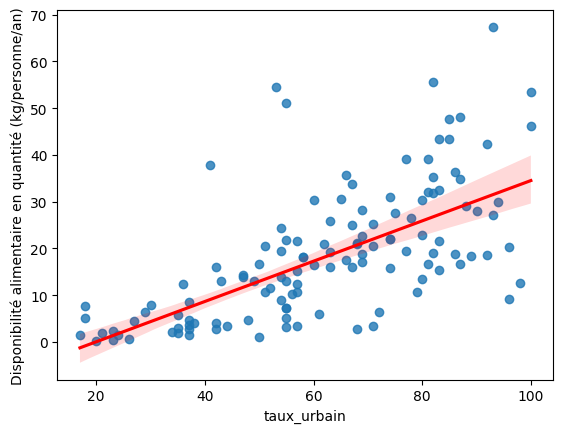

In [ ]:
# test de Spearman

# 1) Visualisation correcte
sns.regplot(data=df_poulet,x='taux_urbain',y='Disponibilité alimentaire en quantité (kg/personne/an)',robust=True,line_kws=dict(color="r"))

# 2) Spearman
spearman_corr, spearman_p_value = spearmanr(df_poulet['taux_urbain'], df_poulet['Disponibilité alimentaire en quantité (kg/personne/an)'])

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

### Etape 4.5 - Matrice de corrélation

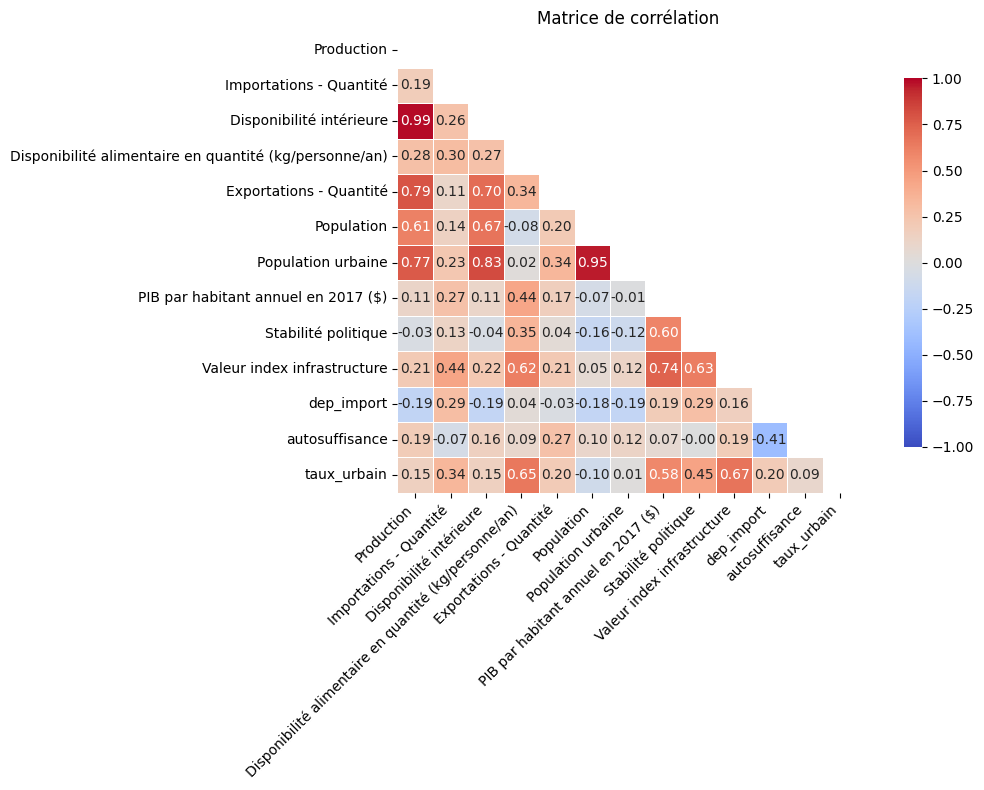

In [ ]:
corr = df_poulet.select_dtypes(include="number").drop(columns=["cluster"], errors="ignore").corr()

# masque du triangle supérieur
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

La matrice de corrélation met en évidence plusieurs relations fortes entre les variables. La production est très fortement corrélée à la disponibilité intérieure, tandis que l’infrastructure est positivement liée à la stabilité politique et à la disponibilité alimentaire. Ces résultats suggèrent que les pays les plus développés et les mieux structurés présentent également un niveau de consommation plus élevé.

# 5 Création du fichier final avant ACP

In [ ]:
df_poulet_final = df_poulet.drop(columns=["Production","Importations - Quantité","Disponibilité intérieure","Population urbaine"])

In [ ]:
df_poulet_final

,Zone,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
0,Albanie,16.36,0.0,2884169,4213.46,0.38,3.56,0.81,0.28,60.0
1,Algérie,6.38,0.0,41389189,4162.15,-0.92,3.56,0.01,0.99,72.0
2,Argentine,42.24,207000000.0,43937140,14660.23,0.17,3.85,0.00,1.10,92.0
3,Arménie,16.06,0.0,2944791,3899.68,-0.62,3.85,0.74,0.23,63.0
4,Allemagne,19.47,646000000.0,82658409,43286.10,0.59,5.96,0.48,0.87,77.0
...,...,...,...,...,...,...,...,...,...,...
120,Venezuela (République bolivarienne du),20.28,0.0,29402484,7865.77,-1.25,2.63,0.04,0.96,96.0
121,Viet Nam,12.33,1000000.0,94600648,2868.14,0.29,3.90,0.24,0.76,36.0
122,Yémen,8.53,0.0,27834819,569.89,-2.94,1.83,0.32,0.68,37.0
123,Zambie,3.42,1000000.0,16853599,1284.93,0.15,2.44,0.20,0.82,44.0


In [ ]:
df_poulet_final.to_csv("final.csv", index=False)